# 神经网络与反向传播

> **斯坦福 CS231n Lecture 4** | Neural Networks and Backpropagation

## 本章导读

本节介绍多层感知机（MLP）和反向传播算法——深度学习的基石。我们将从计算图出发，手算反向传播，然后从零实现一个两层神经网络。

**学习目标：**
- 理解计算图和反向传播原理
- 掌握链式法则在神经网络中的应用
- 从零实现 MLP 并训练

**参考来源：** [CS231n Backpropagation](https://cs231n.github.io/optimization-2/) | [Efficient Backprop](https://cs231n.stanford.edu/papers/lecun-98b.pdf)

## 1. 计算图与反向传播

### 计算图

将数学表达式拆解为基本运算的图：
```
f(x, y) = (x + y) * (y - z)
```
分解为：
- $a = x + y$
- $b = y - z$
- $f = a \times b$

### 链式法则

$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial x}$$

反向传播就是沿计算图反向传播梯度。

## 2. 手算验证

### 示例：$f(x, y, z) = (x + y) \cdot (y - z)$

设 $x=2, y=3, z=1$：
- $a = x + y = 5$
- $b = y - z = 2$
- $f = a \times b = 10$

反向传播：
- $\frac{\partial f}{\partial a} = b = 2$
- $\frac{\partial f}{\partial b} = a = 5$
- $\frac{\partial a}{\partial x} = 1 \Rightarrow \frac{\partial f}{\partial x} = 2 \times 1 = 2$
- $\frac{\partial a}{\partial y} = 1 \Rightarrow \frac{\partial f}{\partial y} = 2 \times 1 + 5 \times 1 = 7$
- $\frac{\partial b}{\partial z} = -1 \Rightarrow \frac{\partial f}{\partial z} = 5 \times (-1) = -5$

In [4]:
# 代码实现：计算图节点
class Node:
    def __init__(self, value=None, grad=None):
        self.value = value
        self.grad = grad
        self._backward = None
    
    def forward(self):
        pass
    
    def backward(self):
        pass

# 手动构建计算图验证
x, y, z = 2, 3, 1
a = x + y  # 5
b = y - z  # 2
f = a * b  # 10
print(f"f = {f}")

# 反向传播
dfda = b  # 2
dfdb = a  # 5
dfdx = dfda * 1  # 2
dfdy = dfda * 1 + dfdb * 1  # 7
dfdz = dfdb * (-1)  # -5
print(f"df/dx = {dfdx}")
print(f"df/dy = {dfdy}")
print(f"df/dz = {dfdz}")

f = 10
df/dx = 2
df/dy = 7
df/dz = -5


训练准确率: 62.50%


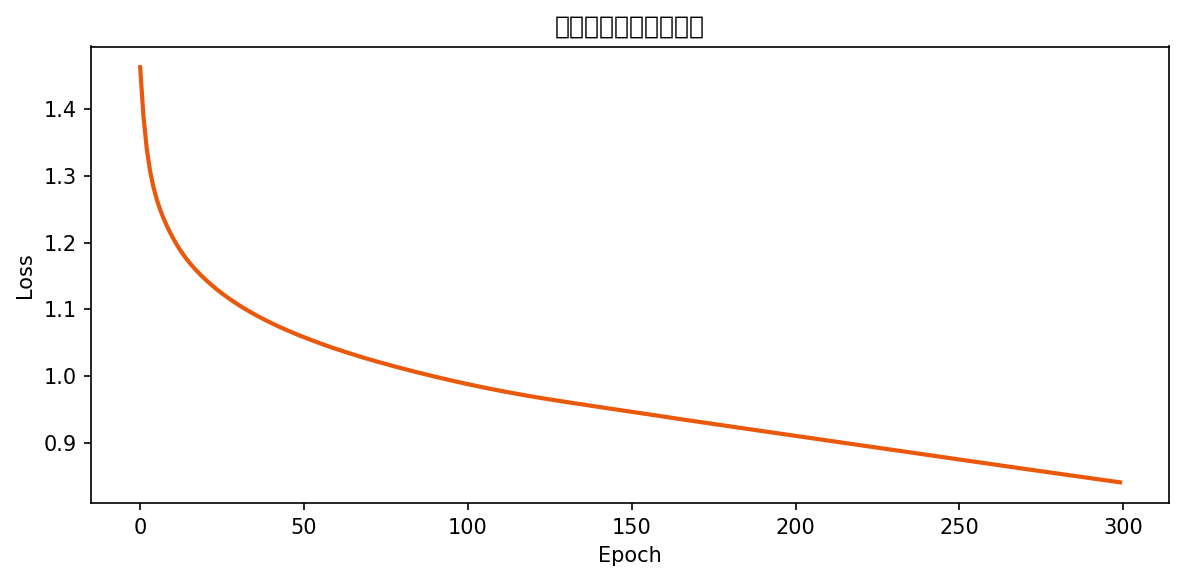

In [5]:
# 从零实现两层神经网络
class TwoLayerNet:
    def __init__(self, input_dim, hidden_dim, num_classes, reg=1e-3):
        self.params = {
            'W1': np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(hidden_dim),
            'W2': np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim),
            'b2': np.zeros(num_classes),
        }
        self.reg = reg
    
    def forward(self, X):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        z1 = X @ W1 + b1
        a1 = np.maximum(0, z1)  # ReLU
        scores = a1 @ W2 + b2
        cache = (X, W1, b1, z1, a1, W2, b2)
        return scores, cache
    
    def loss(self, X, y):
        scores, cache = self.forward(X)
        N = X.shape[0]
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        correct_logprobs = -np.log(probs[np.arange(N), y])
        data_loss = np.sum(correct_logprobs) / N
        reg_loss = 0.5 * self.reg * (np.sum(self.params['W1']**2) + np.sum(self.params['W2']**2))
        loss = data_loss + reg_loss
        
        # 反向传播
        X, W1, b1, z1, a1, W2, b2 = cache
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        dW2 = a1.T @ dscores + self.reg * W2
        db2 = np.sum(dscores, axis=0)
        da1 = dscores @ W2.T
        dz1 = da1 * (z1 > 0)  # ReLU 梯度
        dW1 = X.T @ dz1 + self.reg * W1
        db1 = np.sum(dz1, axis=0)
        grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
        return loss, grads
    
    def train(self, X, y, lr=1e-2, epochs=200):
        losses = []
        for _ in range(epochs):
            loss, grads = self.loss(X, y)
            for k in self.params:
                self.params[k] -= lr * grads[k]
            losses.append(loss)
        return losses

# 测试
np.random.seed(42)
N, D, H, C = 200, 10, 20, 3
X = np.random.randn(N, D)
y = np.random.randint(0, C, N)
net = TwoLayerNet(D, H, C)
losses = net.train(X, y, lr=0.1, epochs=300)
scores, _ = net.forward(X)
pred = np.argmax(scores, axis=1)
acc = np.mean(pred == y)
print(f"训练准确率: {acc:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('两层神经网络训练损失')
plt.tight_layout()
plt.savefig('lecture-04-backprop/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 实验观察：ReLU vs Sigmoid

### 激活函数对比

| 激活函数 | 公式 | 梯度 | 优点 | 缺点 |
|---------|------|------|------|------|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | $\sigma(1-\sigma)$ | 平滑、有界 | 梯度消失、非零中心 |
| **ReLU** | $\max(0, x)$ | $x>0 ? 1 : 0$ | 计算快、不饱和 | 神经元死亡 |
| **Leaky ReLU** | $\max(0.01x, x)$ | $x>0 ? 1 : 0.01$ | 不死亡 | 需调参 |

ReLU 的核心优势在于其在正区间的梯度恒为 1，有效缓解了深度网络的梯度消失问题。

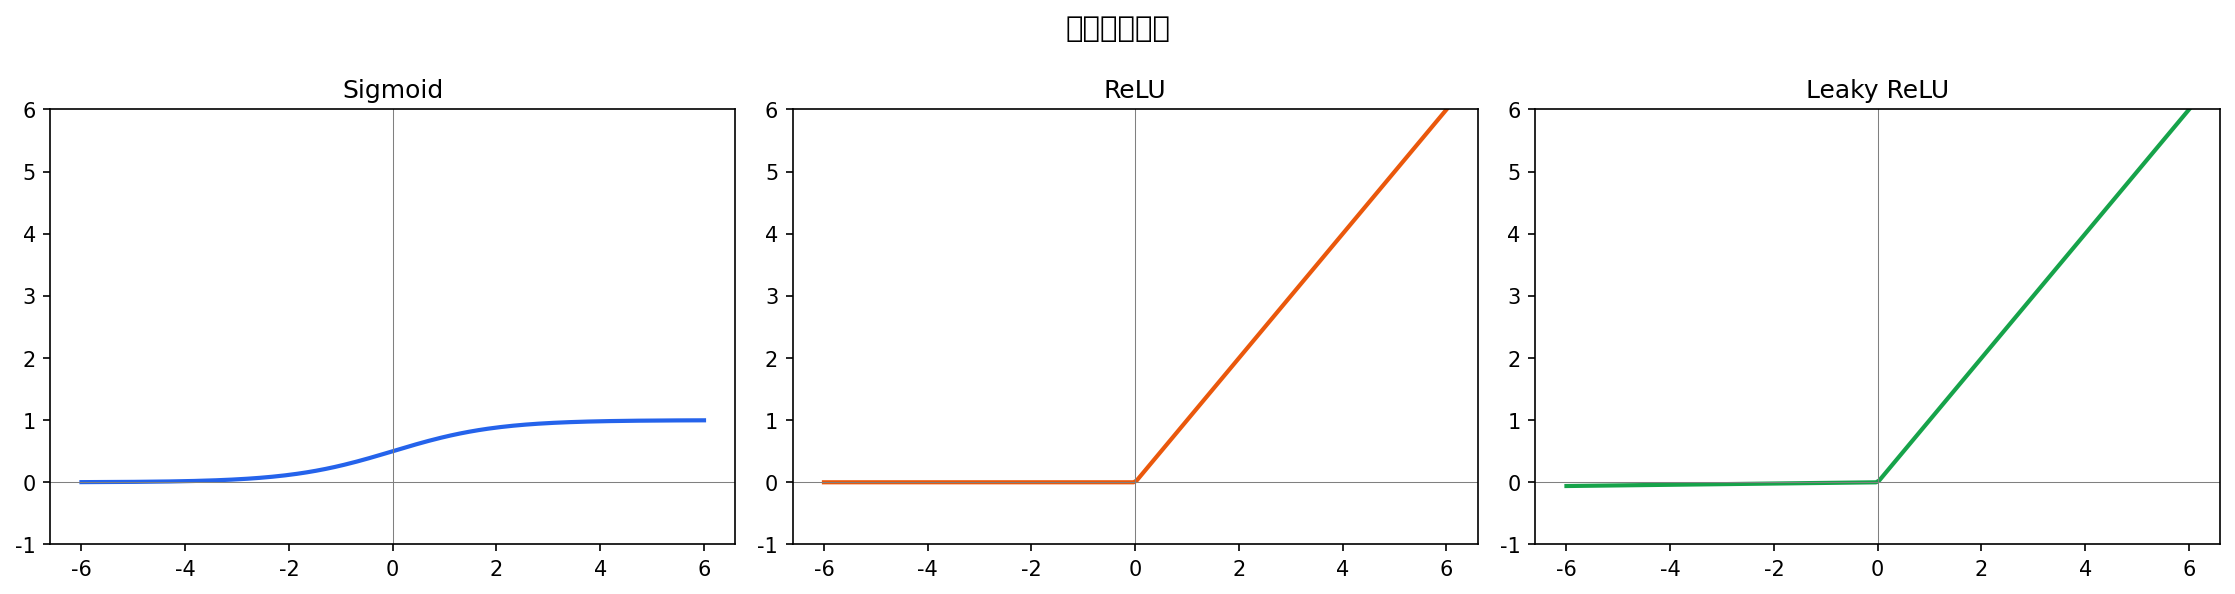

In [7]:
# 激活函数可视化
x = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.01 * x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fn, name, color in zip(axes, [sigmoid, relu, leaky_relu], 
    ['Sigmoid', 'ReLU', 'Leaky ReLU'], ['#2563eb', '#ea580c', '#16a34a']):
    ax.plot(x, fn, color=color, linewidth=2)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(name)
    ax.set_ylim(-1, 6)
plt.suptitle('激活函数比较', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-04-backprop/activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()

## 作业

### 作业 1：实现 Leaky ReLU 的前向和反向传播

In [9]:
# 作业 1：实现 Leaky ReLU
def leaky_relu_forward(x, slope=0.01):
    """Leaky ReLU 前向传播"""
    pass

def leaky_relu_backward(dout, x, slope=0.01):
    """Leaky ReLU 反向传播"""
    pass

x_test = np.array([-2, -1, 0, 1, 2])
out = leaky_relu_forward(x_test)
assert np.allclose(out, [-0.02, -0.01, 0, 1, 2])
print("作业 1 通过!")

TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

## 参考文献

1. **CS231n Backpropagation Notes** - [cs231n.github.io/optimization-2](https://cs231n.github.io/optimization-2/)
2. **Efficient Backprop** - LeCun et al., 1998. [PDF](https://cs231n.stanford.edu/papers/lecun-98b.pdf)
3. **Derivatives Notes** - [cs231n.stanford.edu/handouts/derivatives.pdf](https://cs231n.stanford.edu/handouts/derivatives.pdf)
4. **Deep Learning Book** - Goodfellow et al., 2016. [Chapter 6](http://www.deeplearningbook.org/contents/mlp.html)

---

> 本节内容参考 [Stanford CS231n Lecture 4](https://cs231n.stanford.edu/)